In [13]:
import tensorflow as tf
import numpy as np
from tensorflow import keras
from tensorflow.keras import Model, layers

tf.keras.backend.set_floatx('float64')
keras.backend.set_floatx('float64')


def HenonMap(q, p, Win, Wout, b_in, eta):
    q = tf.cast(q, tf.float64)
    p = tf.cast(p, tf.float64)

    with tf.GradientTape() as tape:
        tape.watch(p)

        # no internal p normalization for now
        hidden = tf.math.tanh(tf.linalg.matmul(p, Win) + b_in)
        V = tf.linalg.matmul(hidden, Wout)

    gradV = tape.gradient(V, p)
    q_out = p + eta
    p_out = -q + gradV
    return q_out, p_out


class HenonLayer(layers.Layer):
    def __init__(self, hidden, dim):
        super().__init__(dtype='float64')
        self.hidden = hidden
        self.dim = dim

    def build(self, input_shape):
        self.Win = self.add_weight(
            shape=(self.dim, self.hidden),
            initializer=tf.keras.initializers.GlorotNormal(),
            dtype='float64',
            trainable=True,
            name='Win'
        )
        self.Wout = self.add_weight(
            shape=(self.hidden, 1),
            initializer=tf.keras.initializers.RandomNormal(stddev=1e-3),
            dtype='float64',
            trainable=True,
            name='Wout'
        )
        self.b_in = self.add_weight(
            shape=(1, self.hidden),
            initializer='zeros',
            dtype='float64',
            trainable=True,
            name='b_in'
        )
        self.eta = self.add_weight(
            shape=(1, self.dim),
            initializer=tf.keras.initializers.RandomNormal(stddev=1e-4),
            dtype='float64',
            trainable=True,
            name='eta'
        )

    def call(self, z):
        z = tf.cast(z, tf.float64)
        q = z[:, :self.dim]
        p = z[:, self.dim:]

        for _ in range(4):
            q, p = HenonMap(q, p, self.Win, self.Wout, self.b_in, self.eta)

        return tf.concat([q, p], axis=1)


class HenonNet(Model):
    def __init__(self, unit_list, dim):
        super().__init__(dtype='float64')
        self.hlayers = [HenonLayer(h, dim) for h in unit_list]

    def call(self, z):
        out = tf.cast(z, tf.float64)
        for layer in self.hlayers:
            out = layer(out)
        return out

In [14]:
data = np.load("xsuite_dataset.npz")

X_raw = data["X"]  # shape (N, 6)
Y = data["Y"]  # shape (N, 6)



print("Original X shape:", X_raw.shape)
print("Original Y shape:", Y.shape)


randomize_indices = np.random.permutation(X_raw.shape[0])
X_raw = X_raw[randomize_indices]
Y = Y[randomize_indices]

Z = X_raw[:, :6]
MU = X_raw[:, 6:9]

print("MU shape:", MU.shape)

into_train = int(0.5 * X_raw.shape[0])

Z_train = tf.convert_to_tensor(Z[:into_train], dtype=tf.float64)
MU_train = tf.convert_to_tensor(MU[:into_train], dtype=tf.float64)
Y_train = tf.convert_to_tensor(Y[:into_train], dtype=tf.float64)
Z_val = tf.convert_to_tensor(Z[into_train:], dtype=tf.float64)
MU_val = tf.convert_to_tensor(MU[into_train:], dtype=tf.float64)
Y_val = tf.convert_to_tensor(Y[into_train:], dtype=tf.float64)


D_train = Y_train - Z_train
D_val   = Y_val - Z_val


print("Training set shapes:", Z_train.shape, Y_train.shape)
print("Test set shapes:", Z_val.shape, Y_val.shape)



Original X shape: (50000, 6)
Original Y shape: (50000, 6)
MU shape: (50000, 0)
Training set shapes: (25000, 6) (25000, 6)
Test set shapes: (25000, 6) (25000, 6)


In [15]:
identity_train = np.mean((Y_train.numpy() - Z_train.numpy())**2)
identity_val   = np.mean((Y_val.numpy()   - Z_val.numpy())**2)

print("identity baseline train:", identity_train)
print("identity baseline val  :", identity_val)

identity baseline train: 2.999259129105031e-06
identity baseline val  : 2.9676345582792257e-06


In [21]:
# output scales from the true transported cloud
y_std = Y_train.numpy().std(axis=0, keepdims=True)

# safe floors so nearly-invariant coordinates do not dominate
scale_floor = np.array([[1e-3, 1e-3, 1e-4, 1e-3, 1e-3, 1e-4]], dtype=np.float64)
y_scale = tf.constant(np.maximum(y_std, scale_floor), dtype=tf.float64)

def batch_cov(x):
    x = x - tf.reduce_mean(x, axis=0, keepdims=True)
    n = tf.cast(tf.shape(x)[0], tf.float64)
    return tf.matmul(x, x, transpose_a=True) / (n - 1.0)

def direct_output_loss(y_true, y_pred,
                       delta=1.0,
                       lam_mean=1e-2,
                       lam_cov=1e-2):
    # 1) robust pointwise term on standardized outputs
    err = (y_pred - y_true) / y_scale
    abs_err = tf.abs(err)
    quad = tf.minimum(abs_err, delta)
    lin = abs_err - quad
    huber = tf.reduce_mean(0.5 * quad**2 + delta * lin)

    # 2) centroid matching
    mean_true = tf.reduce_mean(y_true, axis=0)
    mean_pred = tf.reduce_mean(y_pred, axis=0)
    mean_loss = tf.reduce_mean(tf.square((mean_pred - mean_true) / tf.squeeze(y_scale, axis=0)))

    # 3) covariance matching
    cov_true = batch_cov(y_true)
    cov_pred = batch_cov(y_pred)
    cov_loss = tf.reduce_mean(tf.square(cov_pred - cov_true))

    return huber + lam_mean * mean_loss + lam_cov * cov_loss

In [20]:
D_train = (Y_train - Z_train).numpy()
print("displacement std:", D_train.std(axis=0))
print("displacement mean abs:", np.mean(np.abs(D_train), axis=0))

displacement std: [3.24784974e-03 2.28085849e-03 1.87975921e-04 1.31092798e-03
 6.99049792e-04 1.20110639e-16]
displacement mean abs: [2.58617039e-03 1.81939526e-03 1.50238761e-04 1.04598588e-03
 5.56714858e-04 9.34651451e-17]


In [18]:
beta = 0.5
rmax2 = 25.0

def weighted_scaled_mse(d_true, d_pred):
    err = (d_pred - d_true) / d_scale
    dmag2 = tf.reduce_sum(tf.square(d_true / d_scale), axis=1, keepdims=True)
    w = 1.0 + beta * tf.minimum(dmag2, rmax2)
    return tf.reduce_mean(w * tf.reduce_sum(tf.square(err), axis=1, keepdims=True))

In [23]:
def schedulerHenon(epoch):
    if epoch < 20:
        return 5e-4
    elif epoch < 80:
        return 2e-4
    else:
        return 1e-4

callback = tf.keras.callbacks.LearningRateScheduler(schedulerHenon)


model = HenonNet(unit_list=[16, 16], dim=3)


model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=5e-4,
        clipnorm=1.0
    ),
    loss=direct_output_loss,
    run_eagerly=False
)

history = model.fit(
    Z_train, D_train,
    validation_data=(Z_val, D_val),
    batch_size=512,
    epochs=200,
    verbose=1,
    callbacks=[callback]
)

Epoch 1/200


KeyboardInterrupt: 

In [5]:
print("baseline zero:", np.mean(Y_train.numpy()**2))
print("baseline identity:", np.mean((Y_train.numpy() - Z_train.numpy())**2))

baseline zero: 2.6005992147872735e-06
baseline identity: 2.9621807794598466e-06


In [6]:
rng = np.random.default_rng(seed=2200)
n_particles = 20000


x     = rng.normal(loc=0.0, scale=1e-3, size=(n_particles,))
y     = rng.normal(loc=0.0, scale=1e-3, size=(n_particles,))
zeta  = rng.normal(loc=0.0, scale=1e-3, size=(n_particles,))
px    = rng.normal(loc=0.0, scale=1e-3, size=(n_particles,))
py    = rng.normal(loc=0.0, scale=1e-3, size=(n_particles,))
delta = rng.normal(loc=0.0, scale=1e-3, size=(n_particles,))

data = np.column_stack([x, y, zeta, px, py, delta])

X = tf.convert_to_tensor(data, dtype=tf.float64)

if mu_dim == 0:
    Y_pred = model(X)
else:
    Y_pred = model([X, MU])

Y_pred = Y_pred.numpy()
X_true = np.load("xsuite_dataset.npz")["X"][:n_particles]
Y_true = np.load("xsuite_dataset.npz")["Y"][:n_particles]
mse = np.mean((Y_pred - Y_true)**2)
print("MSE on new random data:", mse)



MSE on new random data: 3.649452900370334e-06


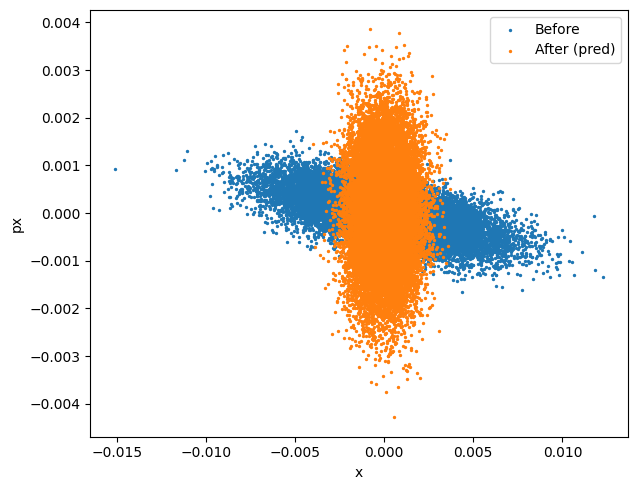

In [8]:
import matplotlib.pyplot as plt

   # true transported states from xsuite
# or compare input vs predicted transport:
# z_in_raw = X_test[:, :6]
labels = ["x", "y", "zeta", "px", "py", "delta"]

index_1 = 0 # 0 for x, 1 for y, 2 for zeta
index_2 = index_1 +3

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 2)
plt.scatter(Y_true[:, index_1], Y_true[:, index_2], s=2, label="Before")
plt.scatter(Y_pred[:, index_1], Y_pred[:, index_2], s=2, label="After (pred)")
plt.xlabel(labels[index_1])
plt.ylabel(labels[index_2])
plt.legend()
#plt.title(f"Transport for kf1={kf1}, kq1={kq1}, kf2={kf2}")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np  # arrays and math
import matplotlib.pyplot as plt  # plots
import xtrack as xt  # tracking module of Xsuite
#%matplotlib widget

print('xtrack version', xt.__version__)

# Reference energy


part = xt.Particles(mass0=xt.PROTON_MASS_EV, p0c=1e9)  # Mass eV/c^2 Momentum in eV/c

# Element geometry
env=xt.Environment()
env.vars.default_to_zero = True
env['l_mq'] = 0.4


env.new('mq', xt.Quadrupole, length='l_mq')
env.new('qf1', 'mq', k1='kf1') # Focusing quadrupole  k1>0
env.new('qf2', 'mq', k1='kf2') # Focusing quadrupole  k1>0
env.new('qd1', 'mq', k1='kd1') # De-focusing quadrupole k1<0
#Markers
env.new("start_cell",xt.Marker)
env.new("end_cell",xt.Marker)


line = env.new_line(
    length=4, # 4 m length
    components=[
    env.place('start_cell', at=0),
    env.place('qf1', at=1),
    env.place('qd1', at=2),   # refer to the center by default
    env.place('qf2', at=3),
    env.place('end_cell',at=4),
    ]
)
line.particle_ref=part
line.build_tracker()   
# generate fresh particles with the SAME distribution as training
rng = np.random.default_rng(2200)
n_particles = 20000

x     = rng.normal(0.0, 1e-3, n_particles)
y     = rng.normal(0.0, 1e-3, n_particles)
zeta  = rng.normal(0.0, 1e-3, n_particles)
px    = rng.normal(0.0, 1e-3, n_particles)
py    = rng.normal(0.0, 1e-3, n_particles)
delta = rng.normal(0.0, 1e-4, n_particles)

z0 = np.column_stack([x, y, zeta, px, py, delta]).astype(np.float64)

p = line.build_particles(
    x=z0[:,0], y=z0[:,1], zeta=z0[:,2],
    px=z0[:,3], py=z0[:,4], delta=z0[:,5]
)
line.track(p)

z1_true = np.column_stack([
    np.array(p.x), np.array(p.y), np.array(p.zeta),
    np.array(p.px), np.array(p.py), np.array(p.delta)
]).astype(np.float64)

X_test = tf.convert_to_tensor(z0, dtype=tf.float64)
Y_pred = model(X_test).numpy()

mse = np.mean((Y_pred - z1_true)**2)
print("Matched test MSE:", mse)